# 04. 가설 2 — 흡연은 간 기능 저하를 유발할 것이다

> 이 노트북은 원본 통합 노트북 `소스_코드_8팀_생체_신호_기반_흡연_여부_비교_시각화_프로젝트__-_종합.ipynb` 의 관련 셀들을 주제별로 재구성한 것입니다. 코드는 원본 그대로 옮겨왔으며(실행 결과만 초기화), 새로 작성하거나 수정한 로직은 없습니다.
>
> 실행하려면 `train_dataset.csv`(Kaggle: Smoker Status Prediction Dataset)를 동일 폴더에 두어야 합니다. 데이터 파일은 저장소에 포함되어 있지 않습니다.
>
> 원본에는 서로 다른 시점에 작성된 3개의 전처리 버전이 섞여 있습니다 (자세한 내용은 `docs/03_issues_and_troubleshooting.md` 참고). 이 재구성본은 그 버전들을 **삭제하거나 하나로 합치지 않고**, 각 노트북 안에서 '버전 A/B/C'로 구분해 모두 보존했습니다.

AST / ALT / γ-GTP 관련 분석을 모아둔 노트북입니다.

> ### ⚠️ 실행 순서 주의 — 파일 순서대로 돌리면 안 됩니다
>
> 이 노트북들은 원본 통합 노트북을 **주제별로** 재배치한 것이라,
> `01 → 02 → … → 06` 순서로 실행하면 변수 정의 순서가 깨집니다.
>
> 구체적으로 — `01` 의 **버전 B** 절이 `train = pd.read_csv(...)` 로 데이터를 다시 읽어
> **버전 A 에서 만든 `BMI_group` 컬럼을 지웁니다.** 그 상태로 `03` 을 실행하면
> `KeyError: 'BMI_group'` 이 납니다. (실제로 확인했습니다 — 파일 순서 실행 시 에러 47건)
>
> **이 노트북에 담긴 출력은 원본 통합 노트북의 셀 순서대로 실행해 얻은 것입니다.**
> 원본 코드셀 106개 중 105개가 매칭됐고, **실행 에러 0건 · 그래프 81개**가 재현됐습니다.
>
> 직접 재현하려면 `원본/소스_코드_8팀….ipynb` 를 순서대로 실행하거나,
> 각 절을 독립적으로 돌리려면 그 절 앞에서 데이터를 다시 읽고 파생 컬럼을 재생성해야 합니다.
>
> 데이터: `data/train_dataset.csv` (저장소 미포함 — [`data/README.md`](../../data/README.md))


## 버전 A — 흡연 여부별 평균 간 수치, 고위험군 비율, 레이더 차트

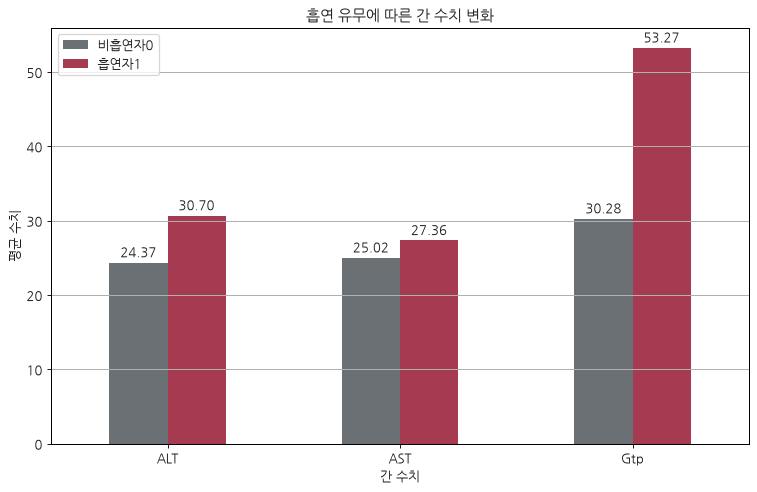

In [ ]:
#가설2 흡연은 간 기능 저하를 유발할 것이다
aag = train.groupby('smoking')[['ALT', 'AST', 'Gtp']].mean()
aag_plot=aag.T
aag_plot.plot(kind="bar", figsize=(10,6),color=[C_NONSMOKER, C_SMOKER])
plt.title('흡연 유무에 따른 간 수치 변화')
plt.xlabel('간 수치')
plt.ylabel('평균 수치')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3)
plt.show()

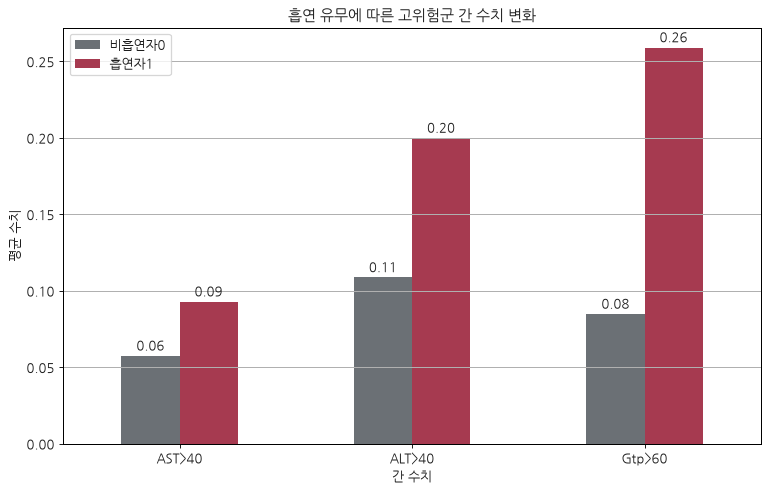

In [ ]:
#고위험군만 따로 분류하기
train['AST>40']= train['AST']> 40
train['ALT>40']= train['ALT']> 40
train['Gtp>60']= train['Gtp']> 60

haag = train.groupby('smoking')[['AST>40', 'ALT>40', 'Gtp>60']].mean()
haag_plot=haag.T
haag_plot.plot(kind="bar", figsize=(10,6),color=[C_NONSMOKER, C_SMOKER])
plt.title('흡연 유무에 따른 고위험군 간 수치 변화')
plt.xlabel('간 수치')
plt.ylabel('평균 수치')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', padding=3)
plt.show()

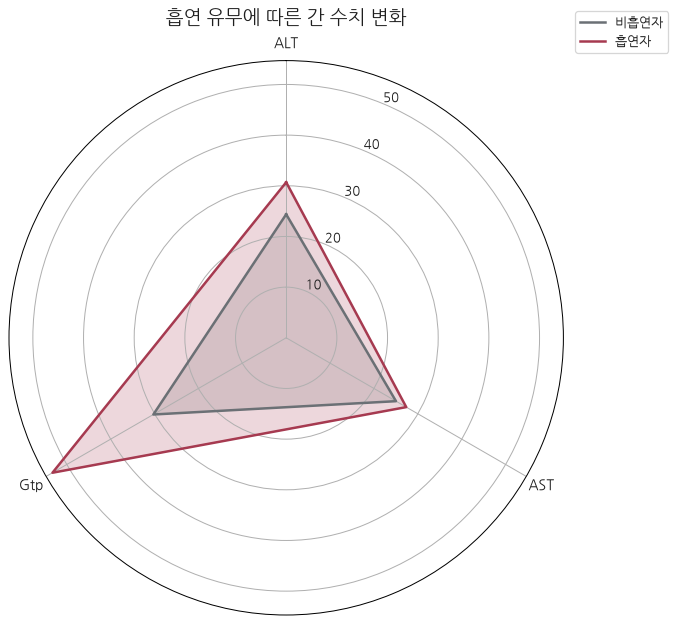

In [ ]:
llen = aag.columns.tolist()
num = len(llen)
angles = [n / float(num) * 2 * pi for n in range(num)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
values_0 = aag.loc[0].tolist()
values_0 += values_0[:1]
ax.plot(angles, values_0, color=C_NONSMOKER, linewidth=2, label='비흡연자')
ax.fill(angles, values_0, color=C_NONSMOKER, alpha=0.2)
values_1 = aag.loc[1].tolist()
values_1 += values_1[:1]
ax.plot(angles, values_1, color=C_SMOKER, linewidth=2, label='흡연자')
ax.fill(angles, values_1, color=C_SMOKER, alpha=0.2)
plt.xticks(angles[:-1], llen, size=11)
plt.title('흡연 유무에 따른 간 수치 변화', pad=30, size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()

## 버전 B — Box/Violin/Histogram 비교

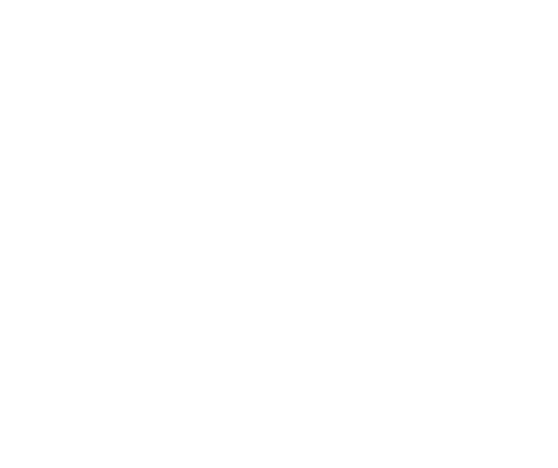

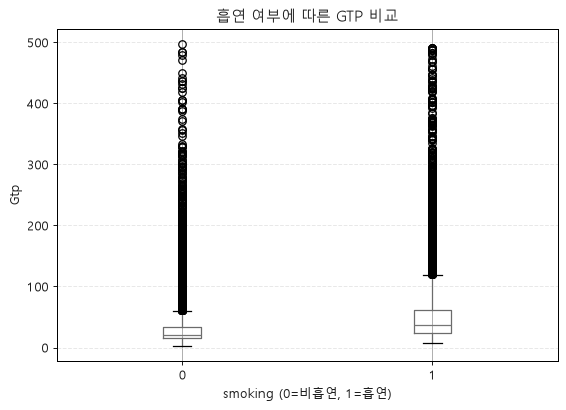

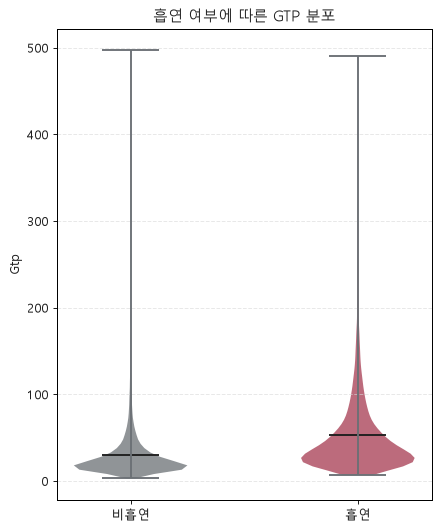

In [ ]:
#가설2_흡연은 간기능저하유발
#세부가설2-1_흡연자는 비흡연자보다 GTP가 더 높게 나타날 것이다
#gtp박스플롯
plt.figure(figsize=(6,5))
train_clean.boxplot(column='Gtp', by='smoking')

plt.title('흡연 여부에 따른 GTP 비교', color=COLOR_TEXT)
plt.suptitle('')
plt.xlabel('smoking (0=비흡연, 1=흡연)')
plt.ylabel('Gtp')
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#gtp바이올린플롯
groups = [
    train_clean[train_clean['smoking']==0]['Gtp'],
    train_clean[train_clean['smoking']==1]['Gtp']
]

fig, ax = plt.subplots(figsize=(5,6))
parts = ax.violinplot(groups, showmeans=True)

parts['bodies'][0].set_facecolor(COLOR_NONSMOKER)
parts['bodies'][1].set_facecolor(COLOR_SMOKER)
for b in parts['bodies']:
    b.set_alpha(0.75)
parts['cmeans'].set_color(COLOR_TEXT)

ax.set_xticks([1,2])
ax.set_xticklabels(['비흡연', '흡연'])
ax.set_ylabel('Gtp')
ax.set_title('흡연 여부에 따른 GTP 분포', color=COLOR_TEXT)
ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

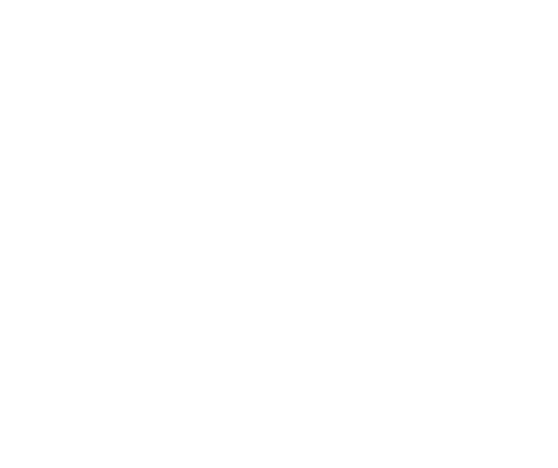

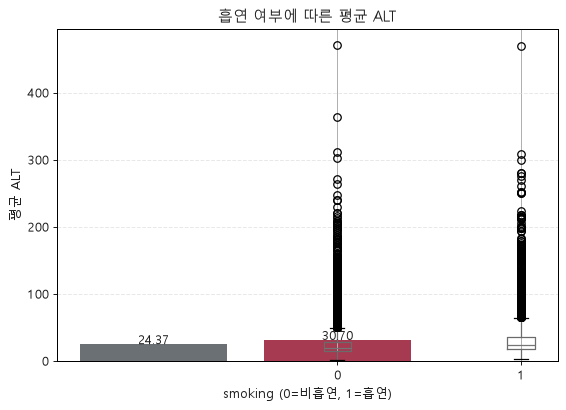

In [ ]:
#가설2_흡연은 간기능저하유발
#세부가설2-2_흡연은 ALT에 악영향을 미칠 것이다

#ALT 박스플롯
plt.figure(figsize=(6,5))
train_clean.boxplot(column='ALT', by='smoking')

plt.title('흡연 여부에 따른 ALT 비교', color=COLOR_TEXT)
plt.suptitle('')
plt.xlabel('smoking (0=비흡연, 1=흡연)')
plt.ylabel('ALT')
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

#ALT 평균 막대그래프
alt_mean = train_clean.groupby('smoking')['ALT'].mean()
alt_mean.index = ['비흡연', '흡연']

bars = plt.bar(alt_mean.index, alt_mean.values, color=[COLOR_NONSMOKER, COLOR_SMOKER])
plt.title('흡연 여부에 따른 평균 ALT', color=COLOR_TEXT)
plt.ylabel('평균 ALT', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(alt_mean.values):
    plt.text(i, v+0.3, f'{v:.2f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

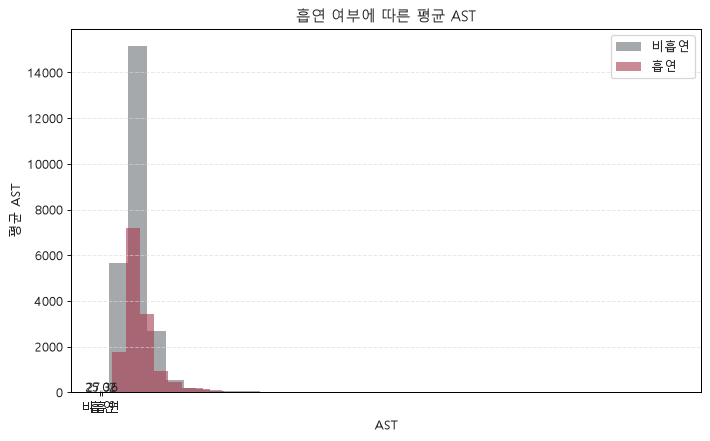

In [ ]:
#세부가설2-3_흡연은AST에악영향
#AST 히스토그램
plt.figure(figsize=(8,5))

plt.hist(train_clean[train_clean['smoking']==0]['AST'], bins=30, alpha=0.6,
         label='비흡연', color=COLOR_NONSMOKER)

plt.hist(train_clean[train_clean['smoking']==1]['AST'], bins=30, alpha=0.6,
         label='흡연', color=COLOR_SMOKER)

plt.title('흡연 여부에 따른 AST 분포 비교', color=COLOR_TEXT)
plt.xlabel('AST')
plt.ylabel('빈도')
plt.legend()
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()
#AST평균막대그래프
ast_mean = train_clean.groupby('smoking')['AST'].mean()
ast_mean.index = ['비흡연', '흡연']

bars = plt.bar(ast_mean.index, ast_mean.values, color=[COLOR_NONSMOKER, COLOR_SMOKER])
plt.title('흡연 여부에 따른 평균 AST', color=COLOR_TEXT)
plt.ylabel('평균 AST', color=COLOR_TEXT)
plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)

for i, v in enumerate(ast_mean.values):
    plt.text(i, v+0.2, f'{v:.2f}', ha='center', color=COLOR_TEXT)

plt.tight_layout()
plt.show()


## 버전 C — BMI·연령대별 세분화 (GTP/ALT/AST/허리둘레)

## 수정 가설 2: 흡연은 간 기능 저하를 유발할 것이다

### 세부가설 2-1: 흡연자는 비흡연자보다 간 효소 GTP가 더 높게 나타날 것이다

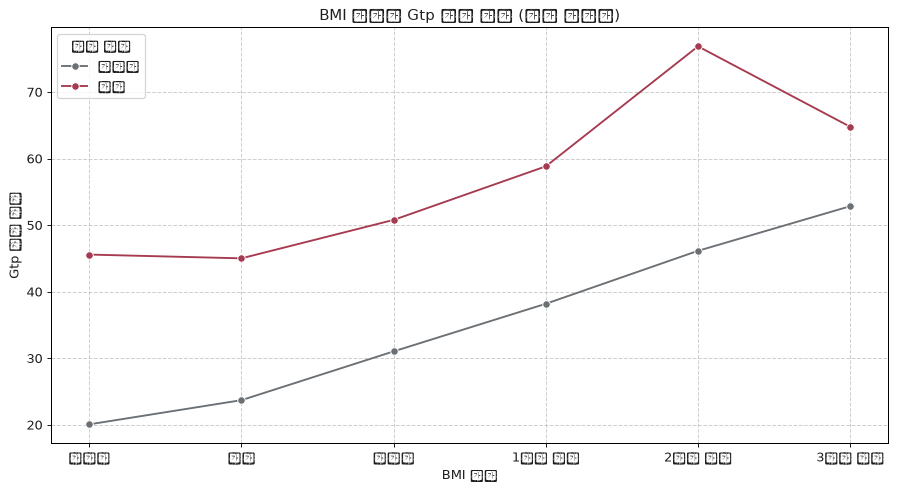

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. BMI 그룹별 Gtp 수치 변화 (흡연 여부별)
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

plt.figure(figsize=(12, 6))
sns.lineplot(data=train_clean, x='bmi_group', y='Gtp', hue='smoking', marker='o', errorbar=None)

plt.title('BMI 그룹별 Gtp 수치 변화 (흡연 여부별)')
plt.xlabel('BMI 그룹')
plt.ylabel('Gtp 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
gtp_bmi_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['Gtp'].mean().unstack()
gtp_bmi_table.columns = ['비흡연', '흡연']
print("--- BMI 그룹별 Gtp 평균 수치 ---")
display(gtp_bmi_table.round(2))

--- BMI 그룹별 Gtp 평균 수치 ---
             비흡연     흡연
bmi_group              
저체중        20.07  45.58
정상         23.71  45.01
과체중        31.04  50.79
1단계 비만     38.19  58.84
2단계 비만     46.15  76.86
3단계 비만     52.85  64.78


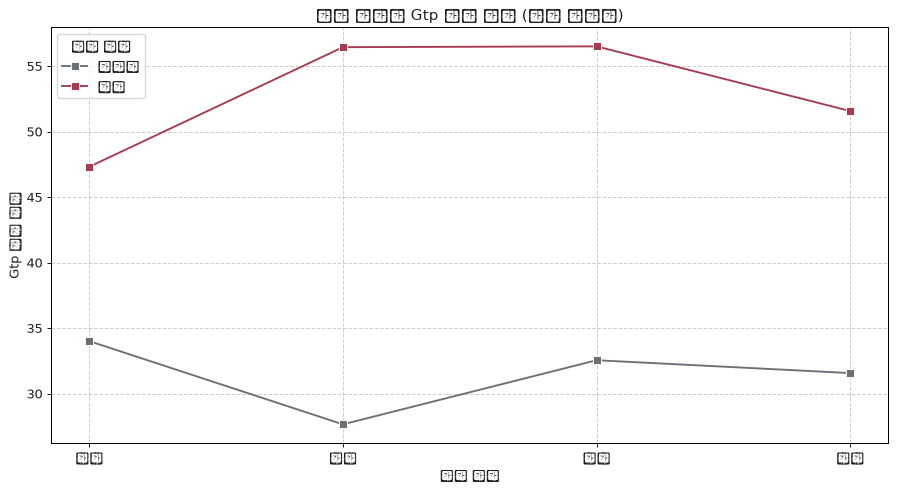

In [ ]:
# 2. 나이 그룹별 Gtp 수치 변화 (흡연 여부별)
age_order = ['청년', '중년', '장년', '노년']

plt.figure(figsize=(12, 6))
sns.lineplot(data=train_clean, x='age_group', y='Gtp', hue='smoking', marker='s', errorbar=None)

plt.title('나이 그룹별 Gtp 수치 변화 (흡연 여부별)')
plt.xlabel('나이 그룹')
plt.ylabel('Gtp 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
gtp_age_table = train_clean.groupby(['age_group', 'smoking'], observed=False)['Gtp'].mean().unstack()
gtp_age_table.columns = ['비흡연', '흡연']
print("--- 나이 그룹별 Gtp 평균 수치 ---")
display(gtp_age_table.round(2))

--- 나이 그룹별 Gtp 평균 수치 ---
             비흡연     흡연
age_group              
청년         34.01  47.32
중년         27.66  56.45
장년         32.56  56.51
노년         31.58  51.57


### 세부가설 2-2: 흡연자는 ALT 에 악영향

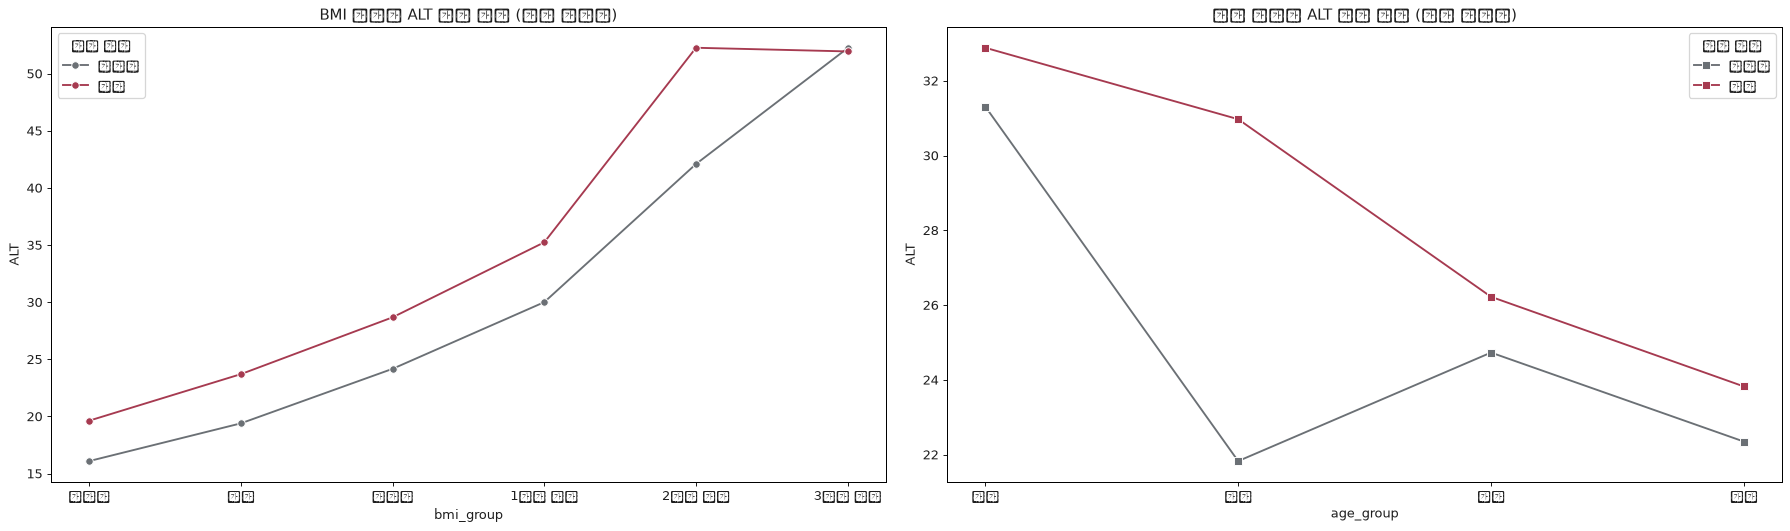

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-2: ALT 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 ALT
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='ALT', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 ALT 수치 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 ALT
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='ALT', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 ALT 수치 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
alt_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['ALT'].mean().unstack()
print("--- BMI 및 나이 그룹별 ALT 수치 요약 ---")
display(alt_table.round(2))

--- BMI 및 나이 그룹별 ALT 수치 요약 ---
smoking        0      1
bmi_group              
저체중        16.09  19.63
정상         19.39  23.70
과체중        24.17  28.67
1단계 비만     30.00  35.24
2단계 비만     42.09  52.26
3단계 비만     52.23  51.94


### 세부가설 2-3: 흡연자는 AST 악영향

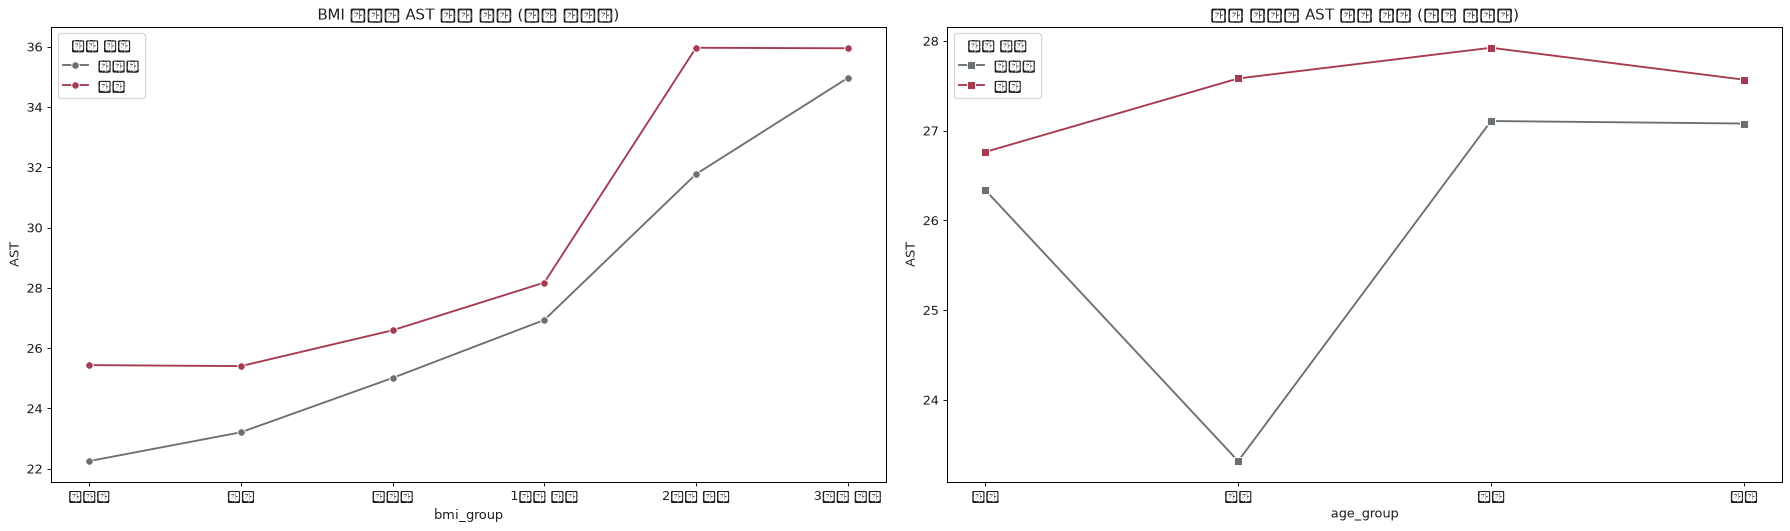

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-3: AST 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 AST
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='AST', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 AST 수치 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 AST
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='AST', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 AST 수치 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
ast_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['AST'].mean().unstack()
print("--- BMI 및 나이 그룹별 AST 수치 요약 ---")
display(ast_table.round(2))

--- BMI 및 나이 그룹별 AST 수치 요약 ---
smoking        0      1
bmi_group              
저체중        22.25  25.44
정상         23.21  25.40
과체중        25.01  26.59
1단계 비만     26.94  28.18
2단계 비만     31.77  35.97
3단계 비만     34.96  35.95


### 세부가설 2-4: 흡연자는 허리둘래에 악영향

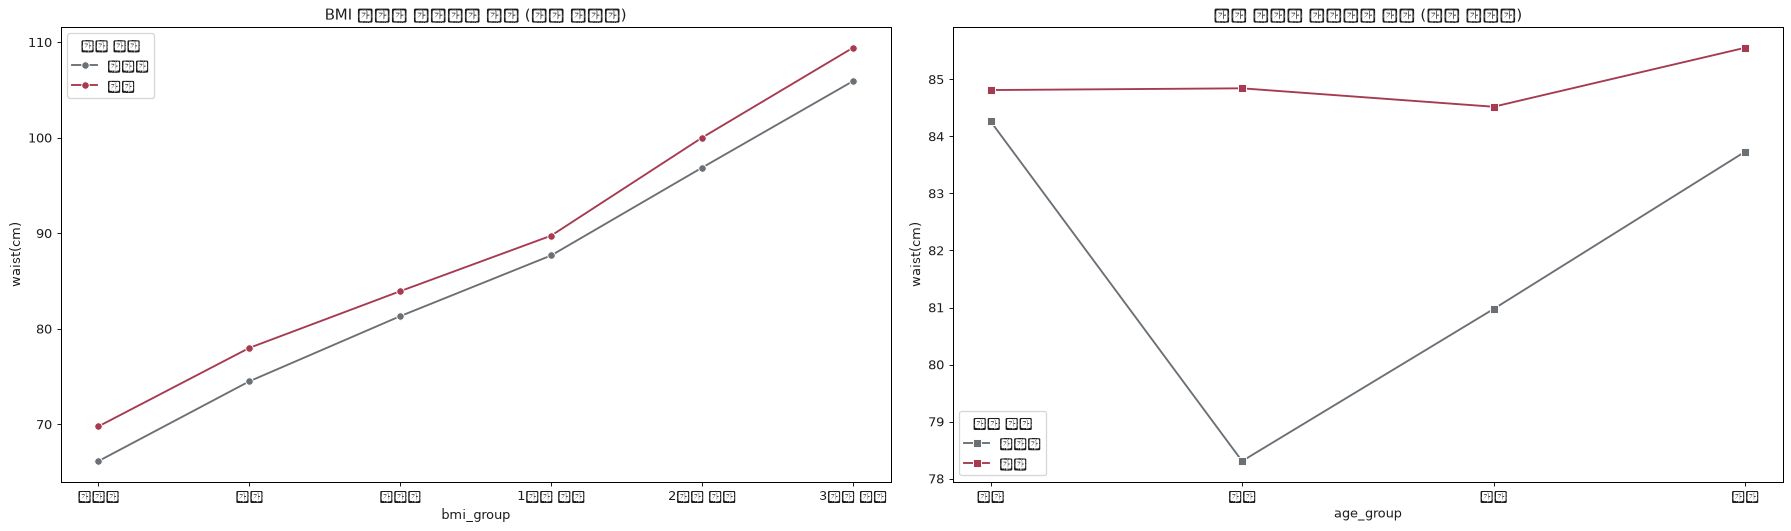

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세부가설 2-4: 허리둘레 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# BMI 그룹별 허리둘레
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='waist(cm)', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 허리둘레 변화 (흡연 여부별)')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])

# 나이 그룹별 허리둘레
sns.lineplot(ax=axes[1], data=train_clean, x='age_group', y='waist(cm)', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('나이 그룹별 허리둘레 변화 (흡연 여부별)')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])

plt.tight_layout()
plt.show()

In [ ]:
waist_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)['waist(cm)'].mean().unstack()
print("--- BMI 및 나이 그룹별 허리둘레 평균 ---")
display(waist_table.round(1))

--- BMI 및 나이 그룹별 허리둘레 평균 ---
smoking        0      1
bmi_group              
저체중         66.2   69.8
정상          74.5   78.0
과체중         81.3   83.9
1단계 비만      87.7   89.7
2단계 비만      96.9  100.0
3단계 비만     105.9  109.4


#### 추가 증빙: GTP/ALT/AST/허리둘래/나이/bmi 상관 관계 계수